Load dataset

In [48]:
import os
import pandas as pd
import numpy as np

"""
    Read .csv files and store data into an array
    format: |LOS|NLOS|data...|
"""
rootdir = '../dataset/UWB-LOS-NLOS-Data-Set/dataset/'
df = pd.DataFrame()
first = 1
for dirpath, _, filenames in os.walk(rootdir):
    for file in filenames:
        filename = os.path.join(dirpath, file)
        print(filename)
        # read data from file
        oneFileDF = pd.read_csv(filename)
        # append to array
        if first > 0:
            first = 0
            df = oneFileDF
        else:
            df = pd.concat([df, oneFileDF], ignore_index=True)

df

../dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part1.csv
../dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part2.csv
../dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part3.csv
../dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part4.csv
../dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part5.csv
../dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part6.csv
../dataset/UWB-LOS-NLOS-Data-Set/dataset/uwb_dataset_part7.csv


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0.0,2.43,745.0,12960.0,17703.0,14948.0,96.0,9987.0,2379.0,276.0,...,180.0,156.0,322.0,378.0,115.0,296.0,452.0,138.0,123.0,0.0
41996,0.0,1.39,745.0,2235.0,15089.0,8796.0,76.0,12559.0,1810.0,281.0,...,43.0,433.0,517.0,518.0,287.0,169.0,437.0,59.0,296.0,0.0
41997,1.0,5.48,747.0,7115.0,6262.0,4584.0,72.0,1435.0,1092.0,1024.0,...,394.0,475.0,262.0,468.0,247.0,192.0,395.0,335.0,284.0,256.0
41998,1.0,3.40,745.0,6662.0,7683.0,5600.0,72.0,1491.0,1077.0,1024.0,...,397.0,170.0,231.0,231.0,202.0,253.0,128.0,311.0,290.0,0.0


Data Feature Extraction
- Extract most relevant features from dataset into dataframe

In [49]:
Features = ['NLOS','RANGE','FP_IDX','FP_AMP1','FP_AMP2','FP_AMP3','CIR_PWR','STDEV_NOISE','MAX_NOISE','RXPACC']
df = df.loc[:, Features]

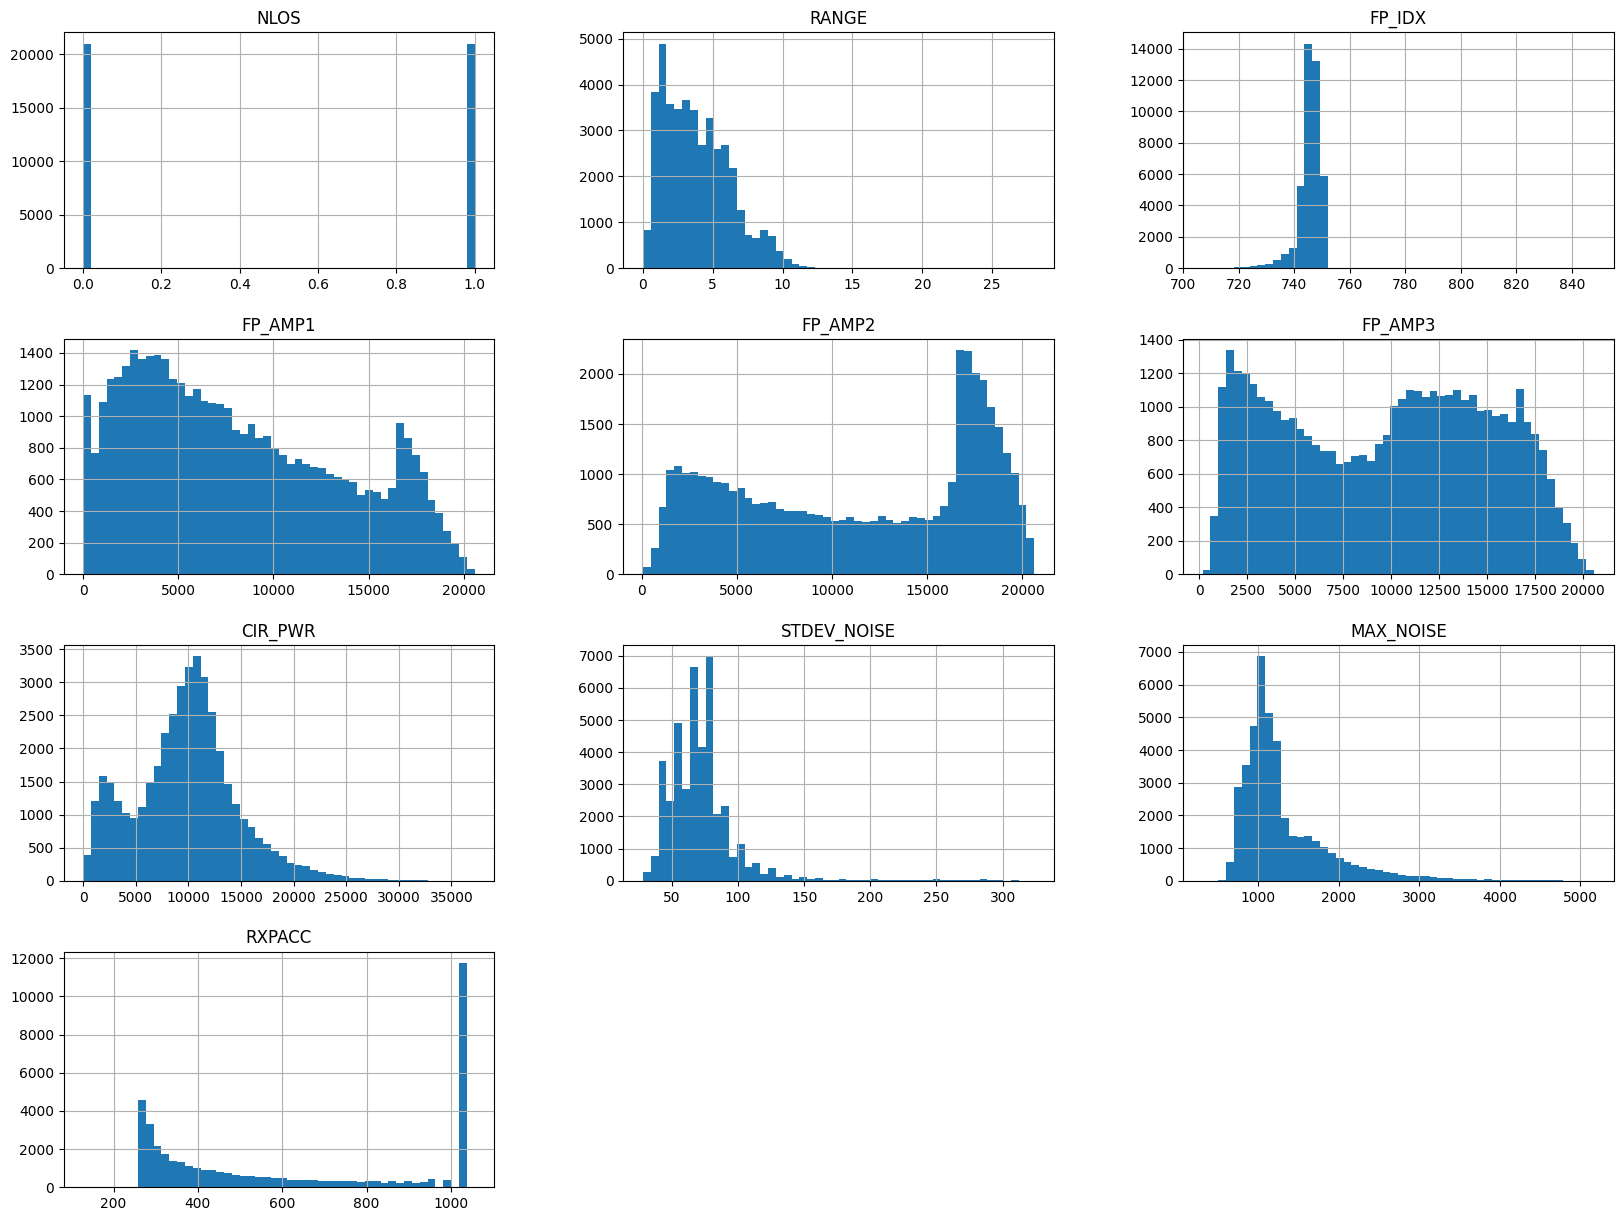

In [50]:
from matplotlib import pyplot as plt

df.hist(bins=50, figsize=(20,15))
plt.show()

- Correlation between STDEV_NOISE and MAX_NOISE is high, and only one should be kept as a feature. So MAX_NOISE is chosen instead of STDEV_NOISE as a feature as it is more cleanly distributed as seen in the histograms

In [51]:
df.corr(numeric_only=True)

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,STDEV_NOISE,MAX_NOISE,RXPACC
NLOS,1.000000,0.456845,-0.316978,-0.447279,-0.524905,-0.514339,-0.392303,0.152291,-0.198198,0.730690
RANGE,0.456845,1.000000,-0.321809,-0.459196,-0.479689,-0.459521,-0.263718,0.089544,-0.260065,0.626349
FP_IDX,-0.316978,-0.321809,1.000000,0.318126,0.442985,0.460630,0.316600,-0.040994,0.106560,-0.382566
FP_AMP1,-0.447279,-0.459196,0.318126,1.000000,0.594008,0.459750,0.341158,-0.058817,0.235854,-0.529544
FP_AMP2,-0.524905,-0.479689,0.442985,0.594008,1.000000,0.886110,0.394945,-0.099765,0.194410,-0.622441
FP_AMP3,-0.514339,-0.459521,0.460630,0.459750,0.886110,1.000000,0.400304,-0.084635,0.184564,-0.594305
CIR_PWR,-0.392303,-0.263718,0.316600,0.341158,0.394945,0.400304,1.000000,-0.033533,0.085846,-0.419276
STDEV_NOISE,0.152291,0.089544,-0.040994,-0.058817,-0.099765,-0.084635,-0.033533,1.000000,0.828995,0.240308
MAX_NOISE,-0.198198,-0.260065,0.106560,0.235854,0.194410,0.184564,0.085846,0.828995,1.000000,-0.223160
RXPACC,0.730690,0.626349,-0.382566,-0.529544,-0.622441,-0.594305,-0.419276,0.240308,-0.223160,1.000000


In [52]:
df = df.drop(columns=['STDEV_NOISE'])

df

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,11855.0,967.0,611.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,18968.0,1133.0,447.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,14699.0,894.0,723.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,8748.0,1127.0,1024.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,11380.0,1744.0,276.0
...,...,...,...,...,...,...,...,...,...
41995,0.0,2.43,745.0,12960.0,17703.0,14948.0,9987.0,2379.0,276.0
41996,0.0,1.39,745.0,2235.0,15089.0,8796.0,12559.0,1810.0,281.0
41997,1.0,5.48,747.0,7115.0,6262.0,4584.0,1435.0,1092.0,1024.0
41998,1.0,3.40,745.0,6662.0,7683.0,5600.0,1491.0,1077.0,1024.0


Data Cleaning
- handle missing values or corrupt data

In [53]:
df.isna().sum()

NLOS         0
RANGE        0
FP_IDX       0
FP_AMP1      0
FP_AMP2      0
FP_AMP3      0
CIR_PWR      0
MAX_NOISE    0
RXPACC       0
dtype: int64

- Check for outliers using z-score filter


In [54]:
from scipy import stats

threshold = 3

for col in range(0, len(df.columns)):
    zscore = np.abs(stats.zscore(df.iloc[:, col]))
    outliers = np.where(zscore > threshold)
    print('Column:', df.columns[col], 'Outliers:', len(outliers[0]))

Column: NLOS Outliers: 0
Column: RANGE Outliers: 114
Column: FP_IDX Outliers: 735
Column: FP_AMP1 Outliers: 0
Column: FP_AMP2 Outliers: 0
Column: FP_AMP3 Outliers: 0
Column: CIR_PWR Outliers: 296
Column: MAX_NOISE Outliers: 918
Column: RXPACC Outliers: 0


- Remove duplicate entries


In [55]:
dupes = df.duplicated()
print('Duplicates:', dupes.sum())

Duplicates: 0


- Ensure correct data types


In [56]:
print(df.dtypes)

NLOS         float64
RANGE        float64
FP_IDX       float64
FP_AMP1      float64
FP_AMP2      float64
FP_AMP3      float64
CIR_PWR      float64
MAX_NOISE    float64
RXPACC       float64
dtype: object


In [57]:
df['NLOS'] = df['NLOS'].astype('int64')
df['FP_IDX'] = df['FP_IDX'].astype('int64')
df['FP_AMP1'] = df['FP_AMP1'].astype('int64')
df['FP_AMP2'] = df['FP_AMP2'].astype('int64')
df['FP_AMP3'] = df['FP_AMP3'].astype('int64')
df['CIR_PWR'] = df['CIR_PWR'].astype('int64')
df['MAX_NOISE'] = df['MAX_NOISE'].astype('int64')
df['RXPACC'] = df['RXPACC'].astype('int64')
print(df.dtypes)

NLOS           int64
RANGE        float64
FP_IDX         int64
FP_AMP1        int64
FP_AMP2        int64
FP_AMP3        int64
CIR_PWR        int64
MAX_NOISE      int64
RXPACC         int64
dtype: object


Save preprocessed data to csv

In [ ]:
df.to_csv('../dataset/UWB-LOS-NLOS-Data-Set/prepared/PreparedDataset.csv', index=False)

In [59]:
# Load full CIR features clearly
cir_columns = [f'CIR{i}' for i in range(1016)]

# Reload the CIR columns from original dataset (before feature selection)
cir_df = pd.DataFrame()
first = 1
for dirpath, _, filenames in os.walk(rootdir):
    for file in filenames:
        filename = os.path.join(dirpath, file)
        oneFileDF = pd.read_csv(filename, usecols=cir_columns + ['RXPACC'])
        if first > 0:
            first = 0
            cir_df = oneFileDF
        else:
            cir_df = pd.concat([cir_df, oneFileDF], ignore_index=True)

# Normalize clearly CIR by RXPACC
cir_df[cir_columns] = cir_df[cir_columns].div(cir_df['RXPACC'], axis=0)

cir_df.head()


,RXPACC,CIR0,CIR1,CIR2,CIR3,CIR4,CIR5,CIR6,CIR7,CIR8,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,611.0,0.211129,0.510638,0.541735,0.230769,0.261866,0.798691,0.319149,0.235679,0.194763,...,0.456628,0.749591,0.299509,0.258592,0.324059,0.142390,0.484452,0.826514,0.502455,0.000000
1,447.0,0.261745,0.364653,0.445190,0.304251,0.317673,0.407159,0.800895,0.275168,0.626398,...,0.322148,0.747204,0.648770,0.510067,0.418345,0.476510,0.451902,0.199105,0.230425,0.000000
2,723.0,0.598893,0.331950,0.322268,0.112033,0.197787,0.699862,0.164592,0.376210,0.343015,...,0.044260,0.515906,0.309820,0.240664,0.171508,0.455048,0.286307,0.132780,0.301521,0.000000
3,1024.0,0.455078,0.241211,0.397461,0.219727,0.272461,0.067383,0.383789,0.425781,0.282227,...,0.246094,0.168945,0.193359,0.156250,0.423828,0.387695,0.283203,0.151367,0.333984,0.250000
4,276.0,0.938406,0.865942,0.206522,0.068841,0.318841,0.793478,1.449275,0.547101,0.355072,...,0.557971,0.757246,0.876812,1.072464,0.315217,0.644928,1.137681,0.894928,1.057971,0.927536


In [60]:
from sklearn.decomposition import PCA

# PCA with 20 components on CIR features clearly
pca = PCA(n_components=10)
cir_pca = pca.fit_transform(cir_df[cir_columns])

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Explained variance output clearly
print('Explained variance per component:', explained_variance_ratio)
print('Cumulative explained variance:', cumulative_explained_variance)


Explained variance per component: [0.34740558 0.22098511 0.07800827 0.05110191 0.03591536 0.02901618
 0.02661144 0.02369718 0.02028873 0.01780327]
Cumulative explained variance: [0.34740558 0.56839069 0.64639896 0.69750087 0.73341623 0.76243241
 0.78904385 0.81274103 0.83302976 0.85083303]


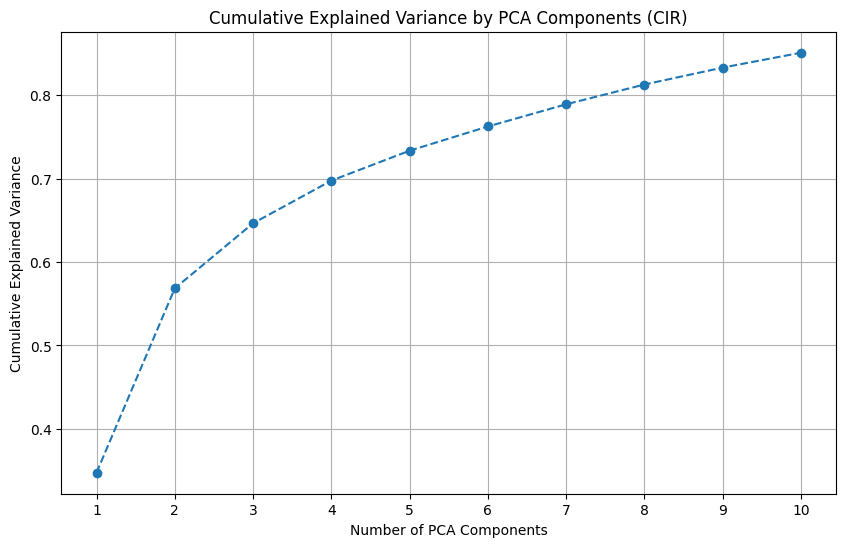

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components (CIR)')
plt.xticks(range(1,11))
plt.grid(True)
plt.show()


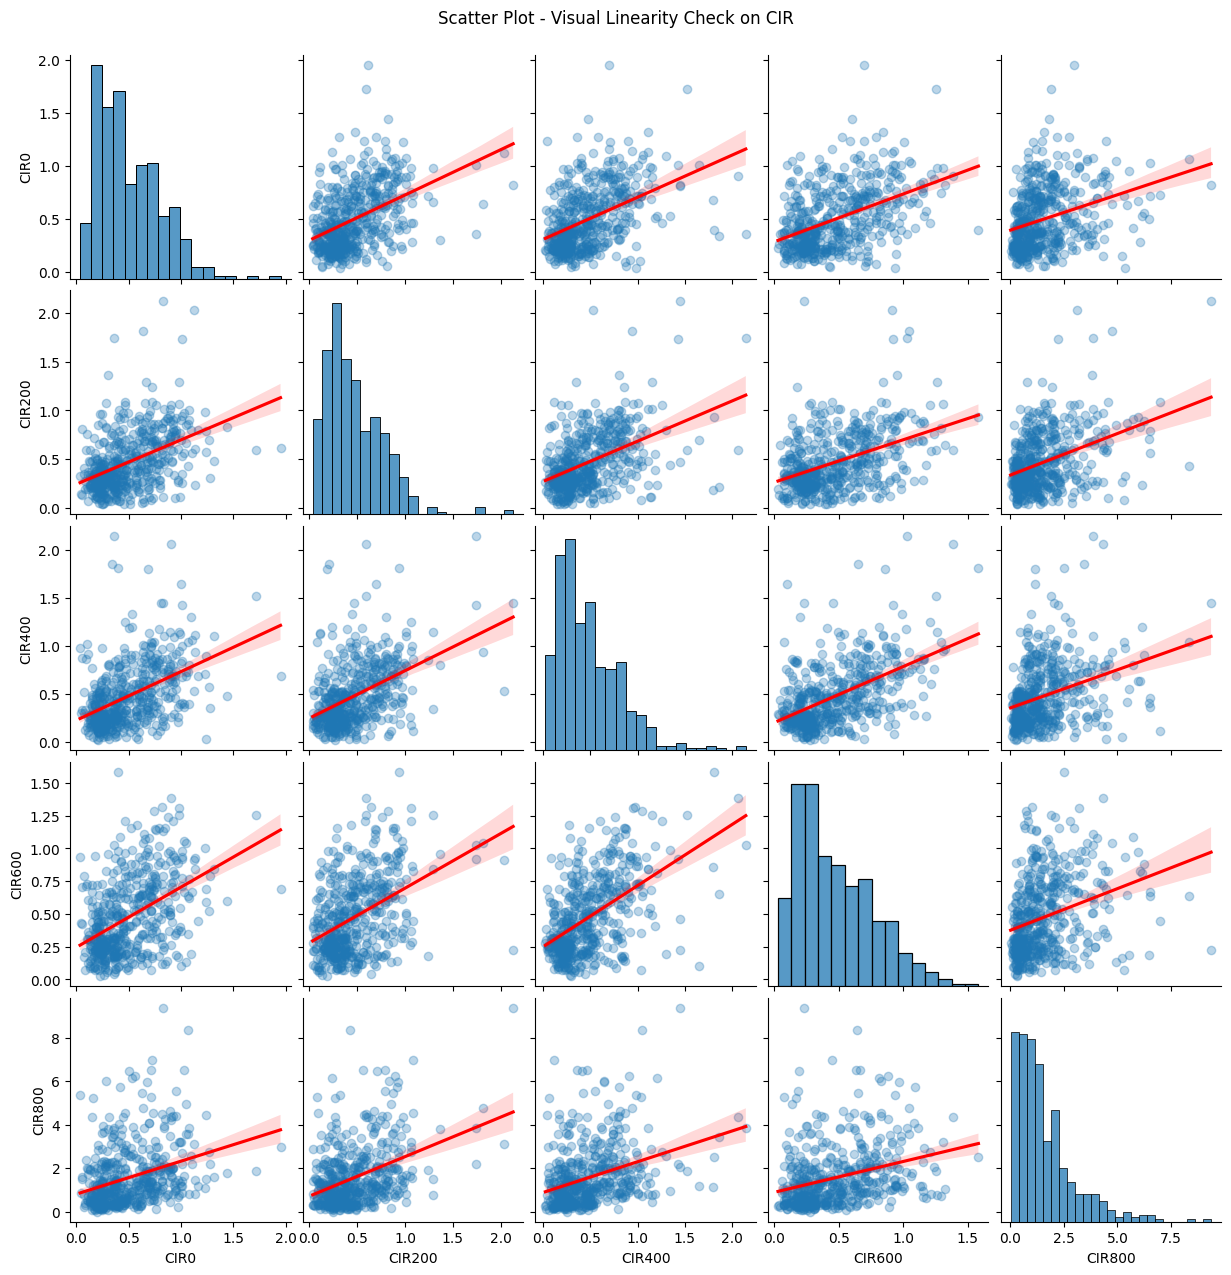

In [63]:
import seaborn as sns

sample_df = cir_df[['CIR0', 'CIR200', 'CIR400', 'CIR600', 'CIR800']].sample(500, random_state=42)

sns.pairplot(sample_df, kind='reg',
             plot_kws={'scatter_kws': {'alpha':0.3}, 'line_kws': {'color':'red'}})
plt.suptitle('Scatter Plot - Visual Linearity Check on CIR', y=1.02)
plt.show()


In [64]:
# Create PCA DataFrame clearly
pca_columns = [f'CIR_PCA{i+1}' for i in range(cir_pca.shape[1])]
cir_pca_df = pd.DataFrame(cir_pca, columns=pca_columns)

# Combine PCA clearly with selected original features
final_df = pd.concat([
    df[['NLOS','RANGE','FP_IDX','FP_AMP1','FP_AMP2','FP_AMP3','CIR_PWR','MAX_NOISE']],
    cir_pca_df
], axis=1)

final_df.head()


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,CIR_PCA1,CIR_PCA2,CIR_PCA3,CIR_PCA4,CIR_PCA5,CIR_PCA6,CIR_PCA7,CIR_PCA8,CIR_PCA9,CIR_PCA10
0,0,3.90,745,18712,10250,11576,11855,967,-10.899240,21.536682,-1.663086,-9.069090,-6.491536,-2.442992,-6.911026,-8.475638,6.141116,-11.581698
1,0,0.66,749,11239,6313,4712,18968,1133,28.390261,-54.587130,-34.088007,-11.310027,-6.324762,-2.996816,2.770960,-1.642750,-13.469135,-11.316175
2,1,7.86,746,4355,5240,3478,14699,894,-17.583033,-20.234498,-10.943063,-11.946257,-3.606774,-0.173685,-2.144201,0.618677,10.593723,4.911456
3,1,3.48,750,8502,8416,5890,8748,1127,-39.103831,-17.167942,-1.792714,-0.216704,-3.921087,-2.407829,-0.807814,0.738071,-3.212761,-4.961820
4,0,1.19,746,17845,18095,12058,11380,1744,55.250058,56.398613,22.352259,-9.362803,-8.034040,-17.333965,-0.793747,23.451713,-28.662173,13.351737


In [65]:
final_df.to_csv('../dataset/UWB-LOS-NLOS-Data-Set/prepared/PreparedDataset_with_PCA.csv', index=False)
